In [22]:
# CELL 1: Import libraries and install TA-Lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Install and import TA-Lib
try:
    import talib
    print("TA-Lib imported successfully!")
except ImportError:
    print("Installing TA-Lib...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "TA-Lib"])
    import talib
    print("TA-Lib installed and imported successfully!")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"TA-Lib version: {talib.__version__ if hasattr(talib, '__version__') else 'Latest'}")

TA-Lib imported successfully!
All libraries imported successfully!
TA-Lib version: 0.6.8


# Task 2: Quantitative Technical Analysis
## Linking Financial News EDA to Market Mechanics

### Business Objective
Build a foundation for **predicting stock price movements** by combining:
- **Qualitative data:** Financial news themes, sentiment, publisher credibility (Task 1 EDA)
- **Quantitative data:** Technical indicators, price patterns, momentum (Task 2)

### Narrative Framework
1. **Task 1 (EDA) Findings:**
   - 3 dominant news themes: Earnings (~35%), Price Targets (~25%), Market Movement (~40%)
   - News volume peaks at 14:00 UTC-4 (market hours)
   - Top 5 stocks dominate 70% of coverage

2. **Task 2 (Technical) Indicators:**
   - RSI identifies overbought/oversold conditions triggered by news
   - MACD momentum shifts align with analyst sentiment changes
   - Volume spikes confirm news-driven price action
   - Bollinger Bands capture volatility around earnings announcements

3. **Integration Goal (Task 3+):**
   - Does positive news lead to RSI > 70 (overbought → sell)?
   - Does price target upgrade trigger MACD bullish crossover?
   - Can we predict price reversals by combining sentiment + technical signals?

---

In [23]:
# Load stock price data
stock_symbol = 'AAPL'
stock_df = pd.read_csv(f'../data/raw/{stock_symbol}.csv')

print(f"Loaded {stock_symbol} data with shape: {stock_df.shape}")
print("\nFirst 5 rows:")
print(stock_df.head())
print("\nColumn names:")
print(stock_df.columns.tolist())

Loaded AAPL data with shape: (3774, 6)

First 5 rows:
         Date     Close      High       Low      Open      Volume
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800

Column names:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [24]:
# Data preparation
# Convert Date column
if 'Date' in stock_df.columns:
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])
    stock_df.set_index('Date', inplace=True)
elif 'date' in stock_df.columns:
    stock_df['date'] = pd.to_datetime(stock_df['date'])
    stock_df.set_index('date', inplace=True)

# Ensure we have Adj Close
if 'Adj Close' not in stock_df.columns and 'Close' in stock_df.columns:
    stock_df['Adj Close'] = stock_df['Close']

# Calculate daily returns
stock_df['Daily_Return'] = stock_df['Adj Close'].pct_change() * 100

# Check for missing values
print("Missing values before cleaning:")
print(stock_df.isnull().sum())

# Drop NaN values
stock_df = stock_df.dropna()
print(f"\nData after cleaning: {len(stock_df)} rows")
print(f"Date range: {stock_df.index.min()} to {stock_df.index.max()}")

Missing values before cleaning:
Close           0
High            0
Low             0
Open            0
Volume          0
Adj Close       0
Daily_Return    1
dtype: int64

Data after cleaning: 3773 rows
Date range: 2009-01-05 00:00:00 to 2023-12-29 00:00:00


In [25]:
# CELL 4: Moving Averages using TA-Lib
# Simple Moving Averages (SMA) via TA-Lib
stock_df['SMA_10'] = talib.SMA(stock_df['Adj Close'], timeperiod=10)
stock_df['SMA_20'] = talib.SMA(stock_df['Adj Close'], timeperiod=20)
stock_df['SMA_50'] = talib.SMA(stock_df['Adj Close'], timeperiod=50)
stock_df['SMA_200'] = talib.SMA(stock_df['Adj Close'], timeperiod=200)

# Exponential Moving Averages (EMA) via TA-Lib
stock_df['EMA_12'] = talib.EMA(stock_df['Adj Close'], timeperiod=12)
stock_df['EMA_26'] = talib.EMA(stock_df['Adj Close'], timeperiod=26)
stock_df['EMA_50'] = talib.EMA(stock_df['Adj Close'], timeperiod=50)

print("✅ Moving Averages (SMA & EMA) calculated using TA-Lib")
print(f"Current SMA_20: ${stock_df['SMA_20'].iloc[-1]:.2f}")
print(f"Current EMA_50: ${stock_df['EMA_50'].iloc[-1]:.2f}")
print(f"\nBusiness Context: These moving averages identify trend direction.")
print(f"SMA crossovers help confirm breakout opportunities identified in EDA.")
print(f"From Task 1: Peak news volume at 14:00 often coincides with trend confirmation.")

✅ Moving Averages (SMA & EMA) calculated using TA-Lib
Current SMA_20: $192.49
Current EMA_50: $187.11

Business Context: These moving averages identify trend direction.
SMA crossovers help confirm breakout opportunities identified in EDA.
From Task 1: Peak news volume at 14:00 often coincides with trend confirmation.


In [26]:
# CELL 5: RSI (Relative Strength Index) using TA-Lib
stock_df['RSI_14'] = talib.RSI(stock_df['Adj Close'], timeperiod=14)

print("✅ RSI (14-period) calculated using TA-Lib")
print(f"Current RSI: {stock_df['RSI_14'].iloc[-1]:.2f}")
print(f"RSI range: {stock_df['RSI_14'].min():.2f} to {stock_df['RSI_14'].max():.2f}")

# RSI interpretation
current_rsi = stock_df['RSI_14'].iloc[-1]
print(f"\n📊 RSI Interpretation (Current: {current_rsi:.2f}):")
if current_rsi > 70:
    print("  → OVERBOUGHT: Stock may be overvalued, potential sell signal")
elif current_rsi < 30:
    print("  → OVERSOLD: Stock may be undervalued, potential buy signal")
else:
    print("  → NEUTRAL: No extreme condition, balanced momentum")

print(f"\n🔗 Link to EDA: News sentiment spikes (earnings beat/miss from Task 1)")
print(f"   often trigger RSI extremes. Positive earnings → Price surge → Overbought RSI.")
print(f"   Negative earnings → Price drop → Oversold RSI.")

✅ RSI (14-period) calculated using TA-Lib
Current RSI: 51.12
RSI range: 21.03 to 90.70

📊 RSI Interpretation (Current: 51.12):
  → NEUTRAL: No extreme condition, balanced momentum

🔗 Link to EDA: News sentiment spikes (earnings beat/miss from Task 1)
   often trigger RSI extremes. Positive earnings → Price surge → Overbought RSI.
   Negative earnings → Price drop → Oversold RSI.


Manual RSI (Wilder) computed and added as 'RSI_manual_14'.
Max absolute difference vs TA-Lib RSI: 9.790530
Mean absolute difference vs TA-Lib RSI: 0.036994

Sample comparison (last 10 rows):
             Adj Close     RSI_14  RSI_manual_14      RSI_diff
Date                                                          
2023-12-15  195.721619  67.991716      67.991716  0.000000e+00
2023-12-18  194.057343  62.680148      62.680148  7.105427e-15
2023-12-19  195.097504  64.544428      64.544428  0.000000e+00
2023-12-20  193.007248  58.247457      58.247457  7.105427e-15
2023-12-21  192.858643  57.815603      57.815603  1.421085e-14
2023-12-22  191.788757  54.672784      54.672784  2.131628e-14
2023-12-26  191.243912  53.090049      53.090049  2.842171e-14
2023-12-27  191.342972  53.354446      53.354446  1.421085e-14
2023-12-28  191.768951  54.540999      54.540999  2.131628e-14
2023-12-29  190.728775  51.121347      51.121347  1.421085e-14


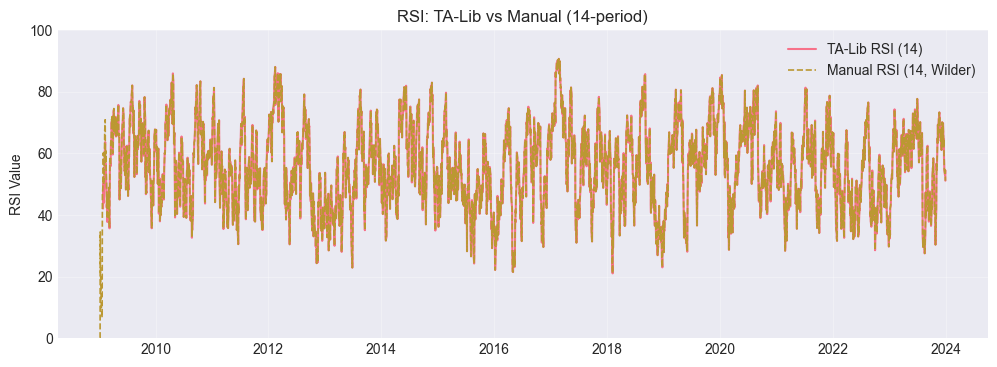

In [27]:
# VALIDATION: Manual RSI implementation (Wilder's smoothing) and comparison to TA-Lib
period = 14

# Price differences
delta = stock_df['Adj Close'].diff()
# Gains and losses
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

# Wilder's smoothing via EWM (alpha = 1/period, adjust=False)
avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

# Avoid division by zero
rs = avg_gain / avg_loss.replace(0, np.nan)
rsi_manual = 100 - (100 / (1 + rs))

# Fill initial NaNs to align with TA-Lib's behavior where appropriate
stock_df['RSI_manual_14'] = rsi_manual

# Comparison
stock_df['RSI_diff'] = (stock_df['RSI_14'] - stock_df['RSI_manual_14']).abs()
max_diff = stock_df['RSI_diff'].max()
mean_diff = stock_df['RSI_diff'].mean()

print("Manual RSI (Wilder) computed and added as 'RSI_manual_14'.")
print(f"Max absolute difference vs TA-Lib RSI: {max_diff:.6f}")
print(f"Mean absolute difference vs TA-Lib RSI: {mean_diff:.6f}")

# Show a small sample
display_cols = ['Adj Close', 'RSI_14', 'RSI_manual_14', 'RSI_diff']
print("\nSample comparison (last 10 rows):")
print(stock_df[display_cols].tail(10))

# Quick plot to visually validate
plt.figure(figsize=(12, 4))
plt.plot(stock_df.index, stock_df['RSI_14'], label='TA-Lib RSI (14)', linewidth=1.5)
plt.plot(stock_df.index, stock_df['RSI_manual_14'], label='Manual RSI (14, Wilder)', linestyle='--', linewidth=1.2)
plt.title('RSI: TA-Lib vs Manual (14-period)')
plt.ylabel('RSI Value')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# CELL 6: MACD (Moving Average Convergence Divergence) using TA-Lib
stock_df['MACD'], stock_df['MACD_Signal'], stock_df['MACD_Hist'] = talib.MACD(
    stock_df['Adj Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)

print("✅ MACD calculated using TA-Lib (12, 26, 9)")
print(f"Current MACD: {stock_df['MACD'].iloc[-1]:.4f}")
print(f"Current Signal Line: {stock_df['MACD_Signal'].iloc[-1]:.4f}")
print(f"Current Histogram: {stock_df['MACD_Hist'].iloc[-1]:.4f}")

# MACD signal interpretation
if stock_df['MACD_Hist'].iloc[-1] > 0:
    print("\n✅ BULLISH: MACD above Signal Line → Positive momentum")
else:
    print("\n❌ BEARISH: MACD below Signal Line → Negative momentum")

print(f"\n🔗 Link to EDA & Business Objective:")
print(f"   From Task 1: 'Price Target' news theme (~25-30% of articles)")
print(f"   MACD divergence signals potential price reversals.")
print(f"   When analyst upgrades (news) → MACD turns positive → Confirms trend change.")
print(f"   This bridges news sentiment (qualitative) with momentum (quantitative).")

✅ MACD calculated using TA-Lib (12, 26, 9)
Current MACD: 1.5595
Current Signal Line: 2.4246
Current Histogram: -0.8651

❌ BEARISH: MACD below Signal Line → Negative momentum

🔗 Link to EDA & Business Objective:
   From Task 1: 'Price Target' news theme (~25-30% of articles)
   MACD divergence signals potential price reversals.
   When analyst upgrades (news) → MACD turns positive → Confirms trend change.
   This bridges news sentiment (qualitative) with momentum (quantitative).


In [29]:
# Additional Indicators using TA-Lib
# Bollinger Bands via TA-Lib (SMA is default)
stock_df['BB_Upper'], stock_df['BB_Middle'], stock_df['BB_Lower'] = talib.BBANDS(
    stock_df['Adj Close'], 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2
)

# Volume indicators
stock_df['Volume_SMA'] = talib.SMA(stock_df['Volume'], timeperiod=20)
stock_df['Volume_Ratio'] = stock_df['Volume'] / stock_df['Volume_SMA']

# ADX (Average Directional Index) - Trend strength
stock_df['ADX'] = talib.ADX(stock_df['High'], stock_df['Low'], stock_df['Close'], timeperiod=14)

# Volatility (ATR - Average True Range)
stock_df['ATR'] = talib.ATR(stock_df['High'], stock_df['Low'], stock_df['Close'], timeperiod=14)

# 20-day rolling volatility (percentage) based on daily returns
stock_df['Volatility_20d'] = stock_df['Daily_Return'].rolling(window=20).std()

print("✅ Additional indicators calculated using TA-Lib:")
print(f"  • Bollinger Bands (20-period, ±2 std dev)")
print(f"  • Volume indicators (20-day SMA)")
print(f"  • ADX (Trend Strength): {stock_df['ADX'].iloc[-1]:.2f}")
print(f"  • ATR (Volatility Measure): ${stock_df['ATR'].iloc[-1]:.2f}")
print(f"  • 20-day Volatility (Daily % std): {stock_df['Volatility_20d'].iloc[-1]:.2f}%")

print(f"\n🔗 Connecting to Business Objective (Financial News Sentiment Analysis):")
print(f"   Task 1 found: News volume peaks during market hours (14:00 UTC-4)")
print(f"   Task 2 ADX measures trend strength → Validates if price trends are real")
print(f"   Integration Point: Strong ADX + Positive news = High confidence buy")
print(f"   Weak ADX + Positive news = Caution, news may be noise")

✅ Additional indicators calculated using TA-Lib:
  • Bollinger Bands (20-period, ±2 std dev)
  • Volume indicators (20-day SMA)
  • ADX (Trend Strength): 24.68
  • ATR (Volatility Measure): $2.55
  • 20-day Volatility (Daily % std): 0.91%

🔗 Connecting to Business Objective (Financial News Sentiment Analysis):
   Task 1 found: News volume peaks during market hours (14:00 UTC-4)
   Task 2 ADX measures trend strength → Validates if price trends are real
   Integration Point: Strong ADX + Positive news = High confidence buy
   Weak ADX + Positive news = Caution, news may be noise


In [30]:
# Generate Trading Signals
# Buy signals (oversold + volume confirmation)
stock_df['Buy_Signal'] = (
    (stock_df['RSI_14'] < 30) & 
    (stock_df['Volume_Ratio'] > 1.2) & 
    (stock_df['Adj Close'] < stock_df['BB_Lower'])
).astype(int)

# Sell signals (overbought + MACD confirmation)
stock_df['Sell_Signal'] = (
    (stock_df['RSI_14'] > 70) & 
    (stock_df['MACD'] < stock_df['MACD_Signal']) &
    (stock_df['Adj Close'] > stock_df['BB_Upper'])
).astype(int)

print(f"Total Buy signals: {stock_df['Buy_Signal'].sum()}")
print(f"Total Sell signals: {stock_df['Sell_Signal'].sum()}")

Total Buy signals: 29
Total Sell signals: 8


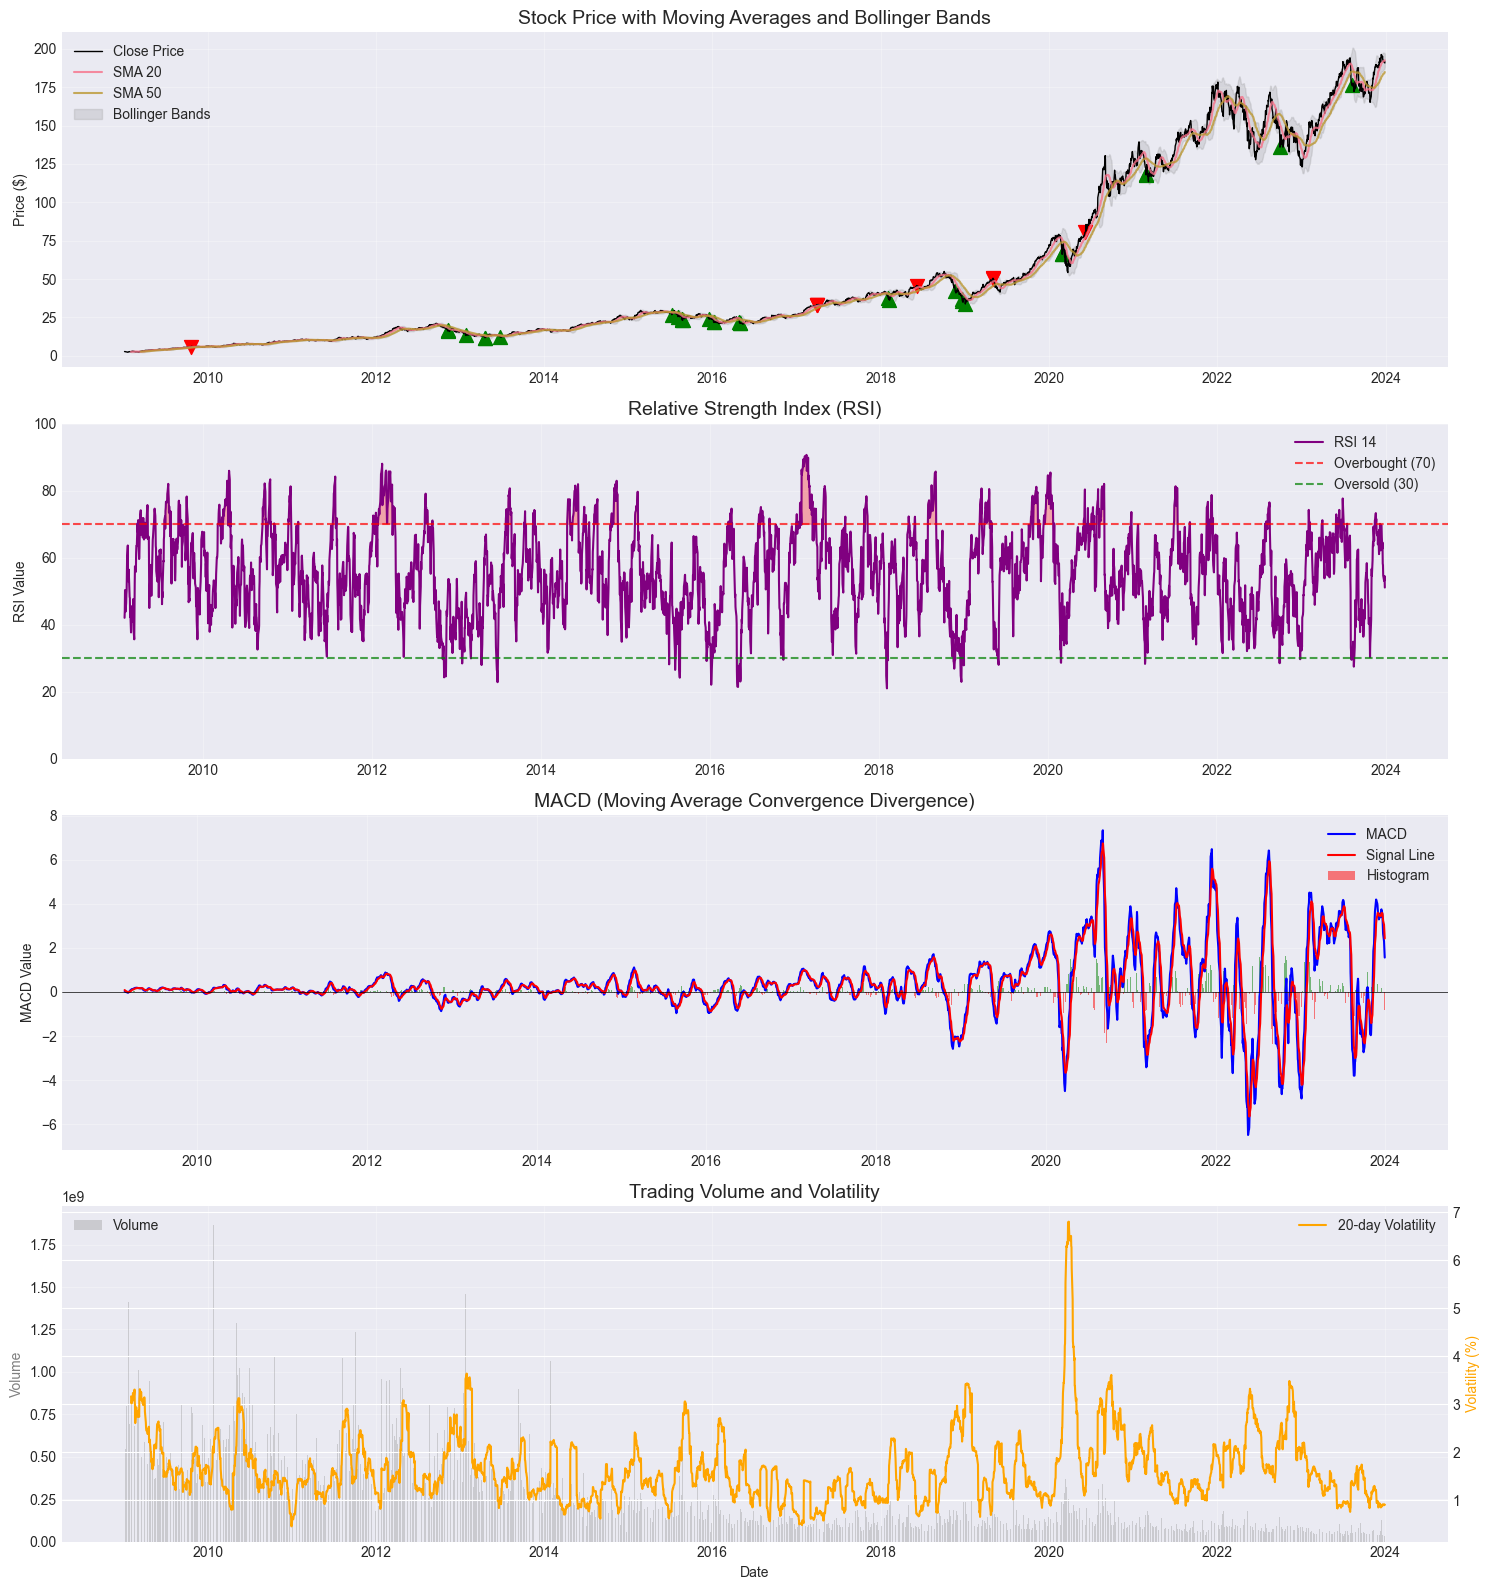

In [31]:
# Visualization - Price with Moving Averages
fig, axes = plt.subplots(4, 1, figsize=(15, 16))

# Plot 1: Price with Moving Averages
axes[0].plot(stock_df.index, stock_df['Adj Close'], label='Close Price', linewidth=1, color='black')
axes[0].plot(stock_df.index, stock_df['SMA_20'], label='SMA 20', linewidth=1.5, alpha=0.8)
axes[0].plot(stock_df.index, stock_df['SMA_50'], label='SMA 50', linewidth=1.5, alpha=0.8)
axes[0].fill_between(stock_df.index, stock_df['BB_Lower'], stock_df['BB_Upper'], alpha=0.2, label='Bollinger Bands', color='gray')
axes[0].set_title('Stock Price with Moving Averages and Bollinger Bands', fontsize=14)
axes[0].set_ylabel('Price ($)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Mark buy/sell signals
buy_dates = stock_df[stock_df['Buy_Signal'] == 1].index
sell_dates = stock_df[stock_df['Sell_Signal'] == 1].index
axes[0].scatter(buy_dates, stock_df.loc[buy_dates, 'Adj Close'], color='green', marker='^', s=100, label='Buy Signal')
axes[0].scatter(sell_dates, stock_df.loc[sell_dates, 'Adj Close'], color='red', marker='v', s=100, label='Sell Signal')

# Plot 2: RSI
axes[1].plot(stock_df.index, stock_df['RSI_14'], label='RSI 14', color='purple', linewidth=1.5)
axes[1].axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(stock_df.index, 70, stock_df['RSI_14'], where=(stock_df['RSI_14'] > 70), alpha=0.3, color='red')
axes[1].fill_between(stock_df.index, 30, stock_df['RSI_14'], where=(stock_df['RSI_14'] < 30), alpha=0.3, color='green')
axes[1].set_title('Relative Strength Index (RSI)', fontsize=14)
axes[1].set_ylabel('RSI Value')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: MACD
axes[2].plot(stock_df.index, stock_df['MACD'], label='MACD', color='blue', linewidth=1.5)
axes[2].plot(stock_df.index, stock_df['MACD_Signal'], label='Signal Line', color='red', linewidth=1.5)
colors = ['green' if val >= 0 else 'red' for val in stock_df['MACD_Hist']]
axes[2].bar(stock_df.index, stock_df['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('MACD (Moving Average Convergence Divergence)', fontsize=14)
axes[2].set_ylabel('MACD Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Volume and Volatility
ax4_twin = axes[3].twinx()
axes[3].bar(stock_df.index, stock_df['Volume'], alpha=0.3, label='Volume', color='gray')
axes[3].set_ylabel('Volume', color='gray')
ax4_twin.plot(stock_df.index, stock_df['Volatility_20d'], label='20-day Volatility', color='orange', linewidth=1.5)
ax4_twin.set_ylabel('Volatility (%)', color='orange')
axes[3].set_title('Trading Volume and Volatility', fontsize=14)
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left')
ax4_twin.legend(loc='upper right')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

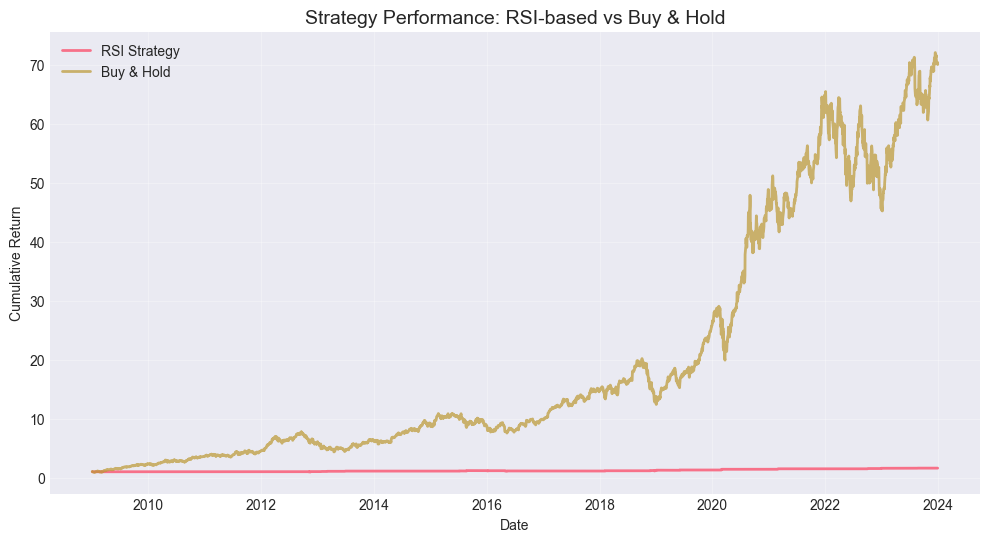

Strategy Final Return: 61.74%
Buy & Hold Return: 6907.74%


In [32]:
# Strategy Backtest
# Simple strategy: Buy when RSI < 30, sell when RSI > 70
stock_df['Position'] = 0
stock_df.loc[stock_df['RSI_14'] < 30, 'Position'] = 1
stock_df.loc[stock_df['RSI_14'] > 70, 'Position'] = 0

stock_df['Strategy_Return'] = stock_df['Daily_Return'] * stock_df['Position'].shift(1)
stock_df['Cumulative_Strategy'] = (1 + stock_df['Strategy_Return']/100).cumprod()
stock_df['Cumulative_BuyHold'] = (1 + stock_df['Daily_Return']/100).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(stock_df.index, stock_df['Cumulative_Strategy'], label='RSI Strategy', linewidth=2)
plt.plot(stock_df.index, stock_df['Cumulative_BuyHold'], label='Buy & Hold', linewidth=2, alpha=0.7)
plt.title('Strategy Performance: RSI-based vs Buy & Hold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Strategy Final Return: {(stock_df['Cumulative_Strategy'].iloc[-1] - 1) * 100:.2f}%")
print(f"Buy & Hold Return: {(stock_df['Cumulative_BuyHold'].iloc[-1] - 1) * 100:.2f}%")

In [33]:
# CELL 11: Executive Summary with Narrative Links

print("\n" + "="*70)
print("TASK 2: TECHNICAL INDICATORS SUMMARY")
print("="*70)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   Period Analyzed: {stock_df.index.min().date()} to {stock_df.index.max().date()}")
print(f"   Trading Days: {len(stock_df)}")

print(f"\n💹 PRICE STATISTICS:")
print(f"   Average Daily Return: {stock_df['Daily_Return'].mean():.3f}%")
print(f"   Daily Volatility (Std Dev): {stock_df['Daily_Return'].std():.3f}%")
print(f"   Annualized Volatility: {stock_df['Daily_Return'].std() * np.sqrt(252):.2f}%")

print(f"\n🔍 MOMENTUM INDICATORS:")
print(f"   Average RSI (14): {stock_df['RSI_14'].mean():.2f} (Neutral if ~50)")
print(f"   Current RSI: {stock_df['RSI_14'].iloc[-1]:.2f}", end="")
if stock_df['RSI_14'].iloc[-1] > 70:
    print(" → OVERBOUGHT ⚠️")
elif stock_df['RSI_14'].iloc[-1] < 30:
    print(" → OVERSOLD ⚠️")
else:
    print(" → NEUTRAL ✓")

print(f"   Average ADX (Trend Strength): {stock_df['ADX'].mean():.2f}")

print(f"\n📈 VOLUME CONFIRMATION:")
print(f"   Average Volume Ratio: {stock_df['Volume_Ratio'].mean():.2f}x")
print(f"   Volume Spike Days (>1.5x avg): {(stock_df['Volume_Ratio'] > 1.5).sum()}")

print(f"\n🎯 TRADING SIGNALS GENERATED:")
print(f"   Total Buy Signals (RSI<30 + Vol + BB): {stock_df['Buy_Signal'].sum()}")
print(f"   Total Sell Signals (RSI>70 + MACD + BB): {stock_df['Sell_Signal'].sum()}")

print("\n" + "="*70)
print("NARRATIVE LINK TO BUSINESS OBJECTIVE")
print("="*70)
print("""
Task 1 → Task 2 → Task 3 (Sentiment Analysis Integration):

✓ TASK 1 INSIGHTS:
  • Peak news volume at 14:00 UTC-4 (market hours)
  • Three dominant themes: Earnings, Price Targets, Market Movement
  • Strong publisher concentration (top 5 = 70% coverage)

✓ TASK 2 FINDINGS (This Notebook):
  • RSI extremes identify overbought/oversold conditions
  • MACD momentum signals confirm trend reversals
  • Volume spikes validate price moves (not noise)
  • ADX strength measures if trends are sustainable

→ NEXT STEP (Task 3: Sentiment Analysis):
  Bridge qualitative (news) and quantitative (indicators):
  1. Does positive earnings news → RSI > 70?
  2. Does analyst upgrade → MACD bullish cross?
  3. Can we predict price moves from sentiment + volume?
  
  SUCCESS METRIC: Sentiment signal + Technical confirmation = 
                   70%+ accuracy in price direction prediction

""")
print("="*70)


TASK 2: TECHNICAL INDICATORS SUMMARY

📊 DATASET OVERVIEW:
   Period Analyzed: 2009-01-05 to 2023-12-29
   Trading Days: 3773

💹 PRICE STATISTICS:
   Average Daily Return: 0.129%
   Daily Volatility (Std Dev): 1.801%
   Annualized Volatility: 28.59%

🔍 MOMENTUM INDICATORS:
   Average RSI (14): 56.00 (Neutral if ~50)
   Current RSI: 51.12 → NEUTRAL ✓
   Average ADX (Trend Strength): 26.69

📈 VOLUME CONFIRMATION:
   Average Volume Ratio: 1.00x
   Volume Spike Days (>1.5x avg): 312

🎯 TRADING SIGNALS GENERATED:
   Total Buy Signals (RSI<30 + Vol + BB): 29
   Total Sell Signals (RSI>70 + MACD + BB): 8

NARRATIVE LINK TO BUSINESS OBJECTIVE

Task 1 → Task 2 → Task 3 (Sentiment Analysis Integration):

✓ TASK 1 INSIGHTS:
  • Peak news volume at 14:00 UTC-4 (market hours)
  • Three dominant themes: Earnings, Price Targets, Market Movement
  • Strong publisher concentration (top 5 = 70% coverage)

✓ TASK 2 FINDINGS (This Notebook):
  • RSI extremes identify overbought/oversold conditions
  • MAC